In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from scipy import signal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor
from sktime.forecasting.compose import EnsembleForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.forecasting.compose import make_reduction
from sklearn.ensemble import RandomForestRegressor
from matplotlib.dates import DateFormatter

np.random.seed(42)

In [15]:
# Load the data
db_offshore = pd.read_csv('data/final_offshore_data_2017_2025.csv')
db_onshore = pd.read_csv('data/final_onshore_data_2017_2025.csv')

## Sarimax (monthly, daily, weekly)

In [65]:
# Write the function to engineer datetime features
def transform_datetime_features(df, correct_days_column='correct_days', start_date='2017-01-01'):

    df = df.copy()
    
    # Split into 'date' and 'hour'
    df[['date', 'hour']] = df[correct_days_column].str.rsplit('-', n=1, expand=True)
    
    # Create datetime column
    df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'].astype(int) - 1, unit='h')
    
    # Extract month
    df['month'] = df['datetime'].dt.to_period('M').astype(str)
    
    # Calculate week number
    start_date = pd.Timestamp(start_date)
    df['week_number'] = ((df['datetime'] - start_date).dt.days // 7) + 1
    
    return df

# Apply the function to both datasets

db_offshore = transform_datetime_features(db_offshore)
db_onshore = transform_datetime_features(db_onshore)

# Drop datetime 2025-01-01 and set datetime as index
db_offshore = db_offshore[db_offshore['datetime'] != '2025-01-01']
db_onshore = db_onshore[db_onshore['datetime'] != '2025-01-01']

db_offshore.set_index('datetime', inplace=True)
db_onshore.set_index('datetime', inplace=True)

# ##### Offshore data
# Convert hourly data to monthly data
db_off_monthly = db_offshore.groupby('month').mean(numeric_only=True)

train_db_m_off = db_off_monthly[db_off_monthly.index <= '2024-06']
test_db_m_off = db_off_monthly[db_off_monthly.index > '2024-06']

# Convert hourly data to weekly data
db_off_weekly = db_offshore.groupby('week_number').mean(numeric_only=True)

train_db_w_off = db_off_weekly[db_off_weekly.index <= 406]
test_db_w_off = db_off_weekly[db_off_weekly.index > 406]

# Convert hourly data to daily data
db_offshore['date'] = pd.to_datetime(db_offshore['date'], format='%Y-%m-%d')
db_off_daily = db_offshore.groupby('date').mean(numeric_only=True)
db_off_daily.index = pd.to_datetime(db_off_daily.index)

train_db_d_off = db_off_daily[db_off_daily.index <= '2024-11-01']
test_db_d_off = db_off_daily[db_off_daily.index > '2024-11-01']

# Set hourly data
db_off_hourly = db_offshore

# Split into train and test set
train_db_h_off = db_off_hourly[db_off_hourly['date'] <= '2024-12-22']
test_db_h_off = db_off_hourly[db_off_hourly['date'] > '2024-12-22']

# ##### Onshore data

# Convert hourly data to monthly data
db_on_monthly = db_onshore.groupby('month').mean(numeric_only=True)

train_db_m_on = db_on_monthly[db_on_monthly.index <= '2024-06']
test_db_m_on = db_on_monthly[db_on_monthly.index > '2024-06']

# Convert hourly data to weekly data
db_on_weekly = db_onshore.groupby('week_number').mean(numeric_only=True)

train_db_w_on = db_on_weekly[db_on_weekly.index <= 406]
test_db_w_on = db_on_weekly[db_on_weekly.index > 406]

# Convert hourly data to daily data
db_onshore['date'] = pd.to_datetime(db_onshore['date'], format='%Y-%m-%d')
db_on_daily = db_onshore.groupby('date').mean(numeric_only=True)
db_on_daily.index = pd.to_datetime(db_on_daily.index)

train_db_d_on = db_on_daily[db_on_daily.index <= '2024-11-01']
test_db_d_on = db_on_daily[db_on_daily.index > '2024-11-01']

# Set hourly data
db_on_hourly = db_onshore

# Split into train and test set
train_db_h_on = db_on_hourly[db_on_hourly['date'] <= '2024-12-22']
test_db_h_on = db_on_hourly[db_on_hourly['date'] > '2024-12-22']

# ### SARIMAX models
# #### Offshore data

def fit_predict_plot_sarimax(train_db, test_db, target_var, exclude_cols=None,
                             order=(3,1,0), seasonal_periods=12):
    if exclude_cols is None:
        exclude_cols = []

    # 1. Prepare exogenous variables
    drop_cols = [col for col in [target_var] + exclude_cols if col in train_db.columns]
    exog_vars = train_db.columns.drop(drop_cols)
    exog_feature_names = exog_vars.tolist()

    scaler = StandardScaler()
    train_exog_scaled = scaler.fit_transform(train_db[exog_vars])
    test_exog_scaled = scaler.transform(test_db[exog_vars])

    # 2. Define seasonal_order based on provided seasonal_periods
    seasonal_order = (1, 1, 1, seasonal_periods)

    # 3. Fit SARIMAX model
    model = SARIMAX(
        train_db[target_var],
        exog=train_exog_scaled,
        order=order,
        seasonal_order=seasonal_order
    )
    model_fit = model.fit(disp=True)

    # 4. Get t-statistics of exogenous coefficients
    exog_coeffs = model_fit.params[model_fit.model.exog_names]
    exog_t_stats = (exog_coeffs / model_fit.bse[model_fit.model.exog_names]).sort_values(ascending=False)

    # 5. Make predictions
    predictions = model_fit.predict(
        start=len(train_db[target_var]),
        end=len(train_db[target_var]) + len(test_db[target_var]) - 1,
        exog=test_exog_scaled,
        dynamic=False
    )

    return model_fit, predictions, exog_t_stats

# ##### Monthly data

model_fit_m_off, predictions_m_off, t_stats_m_off = fit_predict_plot_sarimax(
train_db=train_db_m_off,
test_db=test_db_m_off,
target_var='volume',
exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
order=(3,1,1),
seasonal_periods=12
)


# ##### Weekly data

# Retrieve exogenous variables
exog_vars = train_db_w_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_off[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_off[exog_vars])

# Fit the model
model = SARIMAX(
train_db_w_off['volume'],
exog=train_exog_scaled_w,
order=(3,1,0),  # ARIMA components
seasonal_order=(1,1,1,52)  # Seasonal components
)
model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_w_off = model_fit.predict(
start=len(train_db_w_off['volume']),
end=len(train_db_w_off['volume']) + len(test_db_w_off['volume']) - 1,
exog=test_exog_scaled_w,
dynamic=False)

# Filter 2024 data
#train_subset = train_db_w_off[train_db_w_off.index >= 300]
#test_subset = test_db_w_off[test_db_w_off.index >= 300]
##pred_subset = predictions[predictions.index >= 300]


# ##### Daily data

# Retrieve exogenous variables
exog_vars = train_db_d_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_off[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_off[exog_vars])

# Alternative approach:
stl = STL(train_db_d_off['volume'], period=365)
result = stl.fit()
train_db_d_off['deseasonalized'] = train_db_d_off['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
train_db_d_off['deseasonalized'],
exog=train_exog_scaled_d,
order=(3,1,0),
seasonal_order=(1,1,1,30)
)  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_d_off = model_fit.predict(
start=len(train_db_d_off['volume']),
end=len(train_db_d_off['volume']) + len(test_db_d_off['volume']) - 1,
exog=test_exog_scaled_d,
dynamic=False)

# Filter 2024 data
train_subset = train_db_d_off[train_db_d_off.index >= "2024-01-01"]
test_subset = test_db_d_off[test_db_d_off.index >= "2024-01-01"]
pred_subset = predictions[predictions.index >= "2024-01-01"]

# #### Onshore data

# ##### Monthly data

model_fit_m_on, predictions_m_on, t_stats_m_on = fit_predict_plot_sarimax(
train_db=train_db_m_on,
test_db=test_db_m_on,
target_var='volume',
exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
order=(3,1,1),
seasonal_periods=12
)


# ##### Weekly data

# Retrieve exogenous variables
exog_vars = train_db_w_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_on[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_on[exog_vars])

# Fit the model
model = SARIMAX(
train_db_w_on['volume'],
exog=train_exog_scaled_w,
order=(3,1,0),  # ARIMA components
seasonal_order=(1,1,1,52)  # Seasonal components
)
model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_w_on = model_fit.predict(
start=len(train_db_w_on['volume']),
end=len(train_db_w_on['volume']) + len(test_db_w_on['volume']) - 1,
exog=test_exog_scaled_w,
dynamic=False)

# ##### Daily data

# Retrieve exogenous variables
exog_vars = train_db_d_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_on[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_on[exog_vars])

# Alternative approach:
stl = STL(train_db_d_on['volume'], period=365)
result = stl.fit()
train_db_d_on['deseasonalized'] = train_db_d_on['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
train_db_d_on['deseasonalized'],
exog=train_exog_scaled_d,
order=(3,1,0),
seasonal_order=(1,1,1,30)
)  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_d_on = model_fit.predict(
start=len(train_db_d_on['volume']),
end=len(train_db_d_on['volume']) + len(test_db_d_on['volume']) - 1,
exog=test_exog_scaled_d,
dynamic=False)

# Filter 2024 data
train_subset = train_db_d_on[train_db_d_on.index >= "2024-01-01"]
test_subset = test_db_d_on[test_db_d_on.index >= "2024-01-01"]
pred_subset = predictions[predictions.index >= "2024-01-01"]

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer 

## Ensemble (hourly)

In [195]:
random_state =42

# Offshore prep
db_offshore = pd.read_csv("data/final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
db_offshore = db_offshore[db_offshore['full_datetime'] < "2025-01-01-01"]
# Convert 'correct days' to datetype format for further processing
db_offshore[['date', 'hour']] = db_offshore['correct_days'].str.rsplit('-', n=1, expand=True)
db_offshore['hour'] = db_offshore['hour'].astype(int) - 1
db_offshore['datetime'] = pd.to_datetime(db_offshore['date']) + pd.to_timedelta(db_offshore['hour'], unit='h')
db_offshore = db_offshore.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor',
                                'percentage', 'date', 'correct_days', "wind_speed_h_avg"], axis = 1)
# Set datetime as index
db_offshore = db_offshore.set_index('datetime')

# Split data into target and exogenous variables
y_h = db_offshore['volume']
X_h = db_offshore.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_h, y_test_off_h, X_train_off_h, X_test_off_h = temporal_train_test_split(y_h, X_h, test_size=0.00239)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_off_h)
X_test_norm = preprocessor.transform(X_test_off_h)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_off_h = pd.DataFrame(X_train_norm, columns=X_train_off_h.columns, index=X_train_off_h.index)
X_test_off_h = pd.DataFrame(X_test_norm, columns=X_test_off_h.columns, index=X_test_off_h.index)

# Onshore prep
db_onshore = pd.read_csv("data/final_onshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
db_onshore = db_onshore[db_onshore['full_datetime'] < "2025-01-01-01"]
# Convert 'correct days' to datetype format for further processing
db_onshore[['date', 'hour']] = db_onshore['correct_days'].str.rsplit('-', n=1, expand=True)
db_onshore['hour'] = db_onshore['hour'].astype(int) - 1
db_onshore['datetime'] = pd.to_datetime(db_onshore['date']) + pd.to_timedelta(db_onshore['hour'], unit='h')
db_onshore = db_onshore.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor',
                                'percentage', 'date', 'correct_days', "wind_speed_h_avg"], axis = 1)
# Set datetime as index
db_onshore = db_onshore.set_index('datetime')

# Split data into target and exogenous variables
y_h = db_onshore['volume']
X_h = db_onshore.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_on_h, y_test_on_h, X_train_on_h, X_test_on_h = temporal_train_test_split(y_h, X_h, test_size=0.00239)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_on_h)
X_test_norm = preprocessor.transform(X_test_on_h)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_on_h = pd.DataFrame(X_train_norm, columns=X_train_on_h.columns, index=X_train_on_h.index)
X_test_on_h = pd.DataFrame(X_test_norm, columns=X_test_on_h.columns, index=X_test_on_h.index)

# Forecast offshore
# Define forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_off_h) + 1), freq = 'h')

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 56)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=100, min_samples_leaf = 10, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# With custom weights (must sum to 1)
weights = [0.5, 0.5]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit the ensemble with exogenous variables
weighted_ensemble.fit(y_train_off_h, X=X_train_off_h)

# Generate forecasts
ens_pred_off_h = weighted_ensemble.predict(fh, X=X_test_off_h)

# Forecast onshore
# Define forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_on_h) + 1), freq = 'h')

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 56)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=50, min_samples_leaf = 30, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# With custom weights (must sum to 1)
weights = [0.3, 0.7]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit the ensemble with exogenous variables
weighted_ensemble.fit(y_train_on_h, X=X_train_on_h)
# Generate forecasts
ens_pred_on_h = weighted_ensemble.predict(fh, X=X_test_on_h)


## XGBoost (all granularities)

In [350]:
# Offshore
db_offshore = pd.read_csv("data/final_offshore_data_2017_2025.csv")
db_offshore["date_offshore"] = db_offshore['full_datetime'].str.rsplit('-', n=1).str[0]
db_offshore[['date_offshore', 'hour_offshore']] = db_offshore['correct_days'].str.rsplit('-', n=1, expand=True)
db_offshore['hour_offshore'] = db_offshore['hour_offshore'].astype(int) - 1
db_offshore['datetime_offshore'] = pd.to_datetime(db_offshore['date_offshore']) + pd.to_timedelta(db_offshore['hour_offshore'], unit='h')
db_offshore = db_offshore[db_offshore["date_offshore"] < "2025-01-01"]

db_offshore['month_offshore'] = db_offshore['datetime_offshore'].dt.to_period('M').astype(str)

start_date_offshore = pd.Timestamp('2017-01-01')
db_offshore['week_number_offshore'] = ((db_offshore['datetime_offshore'] - start_date_offshore).dt.days // 7) + 1

db_offshore.set_index('datetime_offshore', inplace=True)

db_offshore["max_capacity_offshore"] = db_offshore["capacity"] / db_offshore["percentage"]
db_offshore["log_volume_offshore"] = np.log1p(db_offshore["volume"])
db_offshore["ratio_VC_offshore"] = db_offshore["volume"] / db_offshore["max_capacity_offshore"]

X_offshore = db_offshore.drop(["volume", "capacity", "emission", "emissionfactor", "log_volume_offshore"], axis=1)
y_offshore = db_offshore["volume"]
y_log_offshore = db_offshore["log_volume_offshore"]
X_train_offshore = X_offshore[X_offshore["date_offshore"] < "2024-12-25"]
X_test_offshore = X_offshore[X_offshore["date_offshore"] >= "2024-12-25"]

y_train_offshore = y_offshore[:X_train_offshore.shape[0]]
y_test_offshore = y_offshore[X_train_offshore.shape[0]:]
y_train_log_offshore = y_log_offshore[:X_train_offshore.shape[0]]
y_test_log_offshore = y_log_offshore[X_train_offshore.shape[0]:]

numeric_features_offshore = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "max_capacity_offshore"]
X_train_offshore = X_train_offshore.loc[:, numeric_features_offshore]
X_test_offshore = X_test_offshore.loc[:, numeric_features_offshore]

preprocessor_offshore = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features_offshore)
])
X_train_norm_offshore = preprocessor_offshore.fit_transform(X_train_offshore)
X_test_norm_offshore = preprocessor_offshore.fit_transform(X_test_offshore)
X_train_offshore = pd.DataFrame(X_train_norm_offshore, columns=X_train_offshore.columns.values, index=X_train_offshore.index.values)
X_test_offshore = pd.DataFrame(X_test_norm_offshore, columns=X_test_offshore.columns.values, index=X_test_offshore.index.values)

param_grid_offshore = {
    'max_depth': [3, 5],
    'n_estimators': [50]
}
model_offshore = XGBRegressor()
grid_offshore = GridSearchCV(model_offshore, param_grid=param_grid_offshore, cv=3)
grid_offshore.fit(X_train_offshore, y_train_offshore)

param_grid_offshore = {
    'max_depth': [5, 7],
    'min_child_weight': [1, 2, 3],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [50, 100, 150],
    'subsample': [0.75, 0.9],
    'colsample_bytree': [0.75, 0.9]
}
XGB_offshore = XGBRegressor(random_state=42)
cv_XGB_offshore = GridSearchCV(estimator=XGB_offshore, param_grid=param_grid_offshore, cv=5)
cv_XGB_offshore.fit(X_train_offshore, y_train_offshore)
XGB_model_offshore = cv_XGB_offshore.best_estimator_
XGB_pred_offshore = XGB_model_offshore.predict(X_test_offshore)

# Monthly
db_monthly_offshore = db_offshore.groupby('month_offshore').mean(numeric_only=True)
train_db_offshore = db_monthly_offshore[db_monthly_offshore.index <= '2024-06']
test_db_offshore = db_monthly_offshore[db_monthly_offshore.index > '2024-06']

X_month_offshore = db_monthly_offshore.drop(["volume", "capacity", "emission", "emissionfactor", "log_volume_offshore", "ratio_VC_offshore"], axis=1)
y_month_log_offshore = db_monthly_offshore["log_volume_offshore"]
y_month_offshore = db_monthly_offshore["volume"]

X_train_month_offshore = X_month_offshore[X_month_offshore.index <= '2024-06']
X_test_month_offshore = X_month_offshore[(X_month_offshore.index > '2024-06')]
y_train_month_log_offshore = y_month_log_offshore[:X_train_month_offshore.shape[0]]
y_test_month_log_offshore = y_month_log_offshore[X_train_month_offshore.shape[0]:]
y_train_month_offshore = y_month_offshore[:X_train_month_offshore.shape[0]]
y_test_month_offshore = y_month_offshore[X_train_month_offshore.shape[0]:]

X_train_month_offshore = X_train_month_offshore.loc[:, numeric_features_offshore]
X_test_month_offshore = X_test_month_offshore.loc[:, numeric_features_offshore]

preprocessor_offshore = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features_offshore)
])
X_train_norm_month_offshore = preprocessor_offshore.fit_transform(X_train_month_offshore)
X_test_norm_month_offshore = preprocessor_offshore.fit_transform(X_test_month_offshore)
X_train_month_offshore = pd.DataFrame(X_train_norm_month_offshore, columns=X_train_month_offshore.columns.values, index=X_train_month_offshore.index.values)
X_test_month_offshore = pd.DataFrame(X_test_norm_month_offshore, columns=X_test_month_offshore.columns.values, index=X_test_month_offshore.index.values)

param_grid_offshore = {
    'max_depth': [5, 7],
    'min_child_weight': [1, 2, 3],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [50, 100, 150],
    'subsample': [0.75, 0.9],
    'colsample_bytree': [0.75, 0.9]
}
XGB_offshore = XGBRegressor(random_state=15)
cv_XGB_month_offshore = GridSearchCV(estimator=XGB_offshore, param_grid=param_grid_offshore, cv=5)
cv_XGB_month_offshore.fit(X_train_month_offshore, y_train_month_offshore)
XGB_model_month_offshore = cv_XGB_month_offshore.best_estimator_
XGB_pred_month_offshore = XGB_model_month_offshore.predict(X_test_month_offshore)

# Weekly
db_weekly_offshore = db_offshore.groupby('week_number_offshore').mean(numeric_only=True)
X_week_offshore = db_weekly_offshore.drop(["volume", "capacity", "emission", "emissionfactor", "log_volume_offshore", "ratio_VC_offshore"], axis=1)
y_week_offshore = db_weekly_offshore["volume"]
X_train_week_offshore = X_week_offshore[X_week_offshore.index <= 406]
X_test_week_offshore = X_week_offshore[(X_week_offshore.index > 406)]
y_train_week_offshore = y_week_offshore[:X_train_week_offshore.shape[0]]
y_test_week_offshore = y_week_offshore[X_train_week_offshore.shape[0]:]

X_train_week_offshore = X_train_week_offshore.loc[:, numeric_features_offshore]
X_test_week_offshore = X_test_week_offshore.loc[:, numeric_features_offshore]

preprocessor_offshore = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features_offshore)
])
X_train_norm_week_offshore = preprocessor_offshore.fit_transform(X_train_week_offshore)
X_test_norm_week_offshore = preprocessor_offshore.fit_transform(X_test_week_offshore)
X_train_week_offshore = pd.DataFrame(X_train_norm_week_offshore, columns=X_train_week_offshore.columns.values, index=X_train_week_offshore.index.values)
X_test_week_offshore = pd.DataFrame(X_test_norm_week_offshore, columns=X_test_week_offshore.columns.values, index=X_test_week_offshore.index.values)

XGB_offshore = XGBRegressor(random_state=15)
cv_XGB_week_offshore = GridSearchCV(estimator=XGB_offshore, param_grid=param_grid_offshore, cv=5)
cv_XGB_week_offshore.fit(X_train_week_offshore, y_train_week_offshore)
XGB_model_week_offshore = cv_XGB_week_offshore.best_estimator_
XGB_pred_week_offshore = XGB_model_week_offshore.predict(X_test_week_offshore)

# Daily
db_offshore['date2_offshore'] = pd.to_datetime(db_offshore['date_offshore'], format='%Y-%m-%d')
db_daily_offshore = db_offshore.groupby('date2_offshore').mean(numeric_only=True)
db_daily_offshore.index = pd.to_datetime(db_daily_offshore.index)

X_day_offshore = db_daily_offshore.drop(["volume", "capacity", "emission", "emissionfactor", "log_volume_offshore", "ratio_VC_offshore"], axis=1)
y_day_offshore = db_daily_offshore["volume"]
X_train_day_offshore = X_day_offshore[X_day_offshore.index <= '2024-11-01']
X_test_day_offshore = X_day_offshore[X_day_offshore.index > '2024-11-01']
y_train_day_offshore = y_day_offshore[:X_train_day_offshore.shape[0]]
y_test_day_offshore = y_day_offshore[X_train_day_offshore.shape[0]:]

X_train_day_offshore = X_train_day_offshore.loc[:, numeric_features_offshore]
X_test_day_offshore = X_test_day_offshore.loc[:, numeric_features_offshore]

preprocessor_offshore = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features_offshore)
])
X_train_norm_day_offshore = preprocessor_offshore.fit_transform(X_train_day_offshore)
X_test_norm_day_offshore = preprocessor_offshore.fit_transform(X_test_day_offshore)
X_train_day_offshore = pd.DataFrame(X_train_norm_day_offshore, columns=X_train_day_offshore.columns.values, index=X_train_day_offshore.index.values)
X_test_day_offshore = pd.DataFrame(X_test_norm_day_offshore, columns=X_test_day_offshore.columns.values, index=X_test_day_offshore.index.values)

XGB_offshore = XGBRegressor(random_state=15)
cv_XGB_day_offshore = GridSearchCV(estimator=XGB_offshore, param_grid=param_grid_offshore, cv=5)
cv_XGB_day_offshore.fit(X_train_day_offshore, y_train_day_offshore)
XGB_model_day_offshore = cv_XGB_day_offshore.best_estimator_
XGB_pred_day_offshore = XGB_model_day_offshore.predict(X_test_day_offshore)

# Onshore
db_onshore = pd.read_csv("data/final_onshore_data_2017_2025.csv")
db_onshore["date_onshore"] = db_onshore['full_datetime'].str.rsplit('-', n=1).str[0]
db_onshore[['date_onshore', 'hour_onshore']] = db_onshore['correct_days'].str.rsplit('-', n=1, expand=True)
db_onshore['hour_onshore'] = db_onshore['hour_onshore'].astype(int) - 1
db_onshore['datetime_onshore'] = pd.to_datetime(db_onshore['date_onshore']) + pd.to_timedelta(db_onshore['hour_onshore'], unit='h')
db_onshore = db_onshore[db_onshore["date_onshore"] < "2025-01-01"]

db_onshore['month_onshore'] = db_onshore['datetime_onshore'].dt.to_period('M').astype(str)

start_date_onshore = pd.Timestamp('2017-01-01')
db_onshore['week_number_onshore'] = ((db_onshore['datetime_onshore'] - start_date_onshore).dt.days // 7) + 1

db_onshore.set_index('datetime_onshore', inplace=True)

db_onshore["max_capacity_onshore"] = db_onshore["capacity"] / db_onshore["percentage"]
db_onshore["log_volume_onshore"] = np.log1p(db_onshore["volume"])
db_onshore["ratio_VC_onshore"] = db_onshore["volume"] / db_onshore["max_capacity_onshore"]

X_onshore = db_onshore.drop(["volume", "capacity", "emission", "emissionfactor", "log_volume_onshore"], axis=1)
y_onshore = db_onshore["volume"]
y_log_onshore = db_onshore["log_volume_onshore"]
X_train_onshore = X_onshore[X_onshore["date_onshore"] < "2024-12-25"]
X_test_onshore = X_onshore[X_onshore["date_onshore"] >= "2024-12-25"]

y_train_onshore = y_onshore[:X_train_onshore.shape[0]]
y_test_onshore = y_onshore[X_train_onshore.shape[0]:]
y_train_log_onshore = y_log_onshore[:X_train_onshore.shape[0]]
y_test_log_onshore = y_log_onshore[X_train_onshore.shape[0]:]

numeric_features_onshore = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "max_capacity_onshore"]
X_train_onshore = X_train_onshore.loc[:, numeric_features_onshore]
X_test_onshore = X_test_onshore.loc[:, numeric_features_onshore]

preprocessor_onshore = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features_onshore)
])
X_train_norm_onshore = preprocessor_onshore.fit_transform(X_train_onshore)
X_test_norm_onshore = preprocessor_onshore.fit_transform(X_test_onshore)
X_train_onshore = pd.DataFrame(X_train_norm_onshore, columns=X_train_onshore.columns.values, index=X_train_onshore.index.values)
X_test_onshore = pd.DataFrame(X_test_norm_onshore, columns=X_test_onshore.columns.values, index=X_test_onshore.index.values)

param_grid_onshore = {
    'max_depth': [3, 5],
    'n_estimators': [50]
}
model_onshore = XGBRegressor()
grid_onshore = GridSearchCV(model_onshore, param_grid=param_grid_onshore, cv=3)
grid_onshore.fit(X_train_onshore, y_train_onshore)

param_grid_onshore = {
    'max_depth': [5, 7],
    'min_child_weight': [1, 2, 3],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [50, 100, 150],
    'subsample': [0.75, 0.9],
    'colsample_bytree': [0.75, 0.9]
}
XGB_onshore = XGBRegressor(random_state=42)
cv_XGB_onshore = GridSearchCV(estimator=XGB_onshore, param_grid=param_grid_onshore, cv=5)
cv_XGB_onshore.fit(X_train_onshore, y_train_onshore)
XGB_model_onshore = cv_XGB_onshore.best_estimator_
XGB_pred_onshore = XGB_model_onshore.predict(X_test_onshore)

# Monthly
db_monthly_onshore = db_onshore.groupby('month_onshore').mean(numeric_only=True)
train_db_onshore = db_monthly_onshore[db_monthly_onshore.index <= '2024-06']
test_db_onshore = db_monthly_onshore[db_monthly_onshore.index > '2024-06']

X_month_onshore = db_monthly_onshore.drop(["volume", "capacity", "emission", "emissionfactor", "log_volume_onshore", "ratio_VC_onshore"], axis=1)
y_month_log_onshore = db_monthly_onshore["log_volume_onshore"]
y_month_onshore = db_monthly_onshore["volume"]

X_train_month_onshore = X_month_onshore[X_month_onshore.index <= '2024-06']
X_test_month_onshore = X_month_onshore[(X_month_onshore.index > '2024-06')]
y_train_month_log_onshore = y_month_log_onshore[:X_train_month_onshore.shape[0]]
y_test_month_log_onshore = y_month_log_onshore[X_train_month_onshore.shape[0]:]
y_train_month_onshore = y_month_onshore[:X_train_month_onshore.shape[0]]
y_test_month_onshore = y_month_onshore[X_train_month_onshore.shape[0]:]

X_train_month_onshore = X_train_month_onshore.loc[:, numeric_features_onshore]
X_test_month_onshore = X_test_month_onshore.loc[:, numeric_features_onshore]

preprocessor_onshore = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features_onshore)
])
X_train_norm_month_onshore = preprocessor_onshore.fit_transform(X_train_month_onshore)
X_test_norm_month_onshore = preprocessor_onshore.fit_transform(X_test_month_onshore)
X_train_month_onshore = pd.DataFrame(X_train_norm_month_onshore, columns=X_train_month_onshore.columns.values, index=X_train_month_onshore.index.values)
X_test_month_onshore = pd.DataFrame(X_test_norm_month_onshore, columns=X_test_month_onshore.columns.values, index=X_test_month_onshore.index.values)

XGB_onshore = XGBRegressor(random_state=15)
cv_XGB_month_onshore = GridSearchCV(estimator=XGB_onshore, param_grid=param_grid_onshore, cv=5)
cv_XGB_month_onshore.fit(X_train_month_onshore, y_train_month_onshore)
XGB_model_month_onshore = cv_XGB_month_onshore.best_estimator_
XGB_pred_month_onshore = XGB_model_month_onshore.predict(X_test_month_onshore)

# Weekly
db_weekly_onshore = db_onshore.groupby('week_number_onshore').mean(numeric_only=True)
X_week_onshore = db_weekly_onshore.drop(["volume", "capacity", "emission", "emissionfactor", "log_volume_onshore", "ratio_VC_onshore"], axis=1)
y_week_onshore = db_weekly_onshore["volume"]
X_train_week_onshore = X_week_onshore[X_week_onshore.index <= 406]
X_test_week_onshore = X_week_onshore[(X_week_onshore.index > 406)]
y_train_week_onshore = y_week_onshore[:X_train_week_onshore.shape[0]]
y_test_week_onshore = y_week_onshore[X_train_week_onshore.shape[0]:]

X_train_week_onshore = X_train_week_onshore.loc[:, numeric_features_onshore]
X_test_week_onshore = X_test_week_onshore.loc[:, numeric_features_onshore]

preprocessor_onshore = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features_onshore)
])
X_train_norm_week_onshore = preprocessor_onshore.fit_transform(X_train_week_onshore)
X_test_norm_week_onshore = preprocessor_onshore.fit_transform(X_test_week_onshore)
X_train_week_onshore = pd.DataFrame(X_train_norm_week_onshore, columns=X_train_week_onshore.columns.values, index=X_train_week_onshore.index.values)
X_test_week_onshore = pd.DataFrame(X_test_norm_week_onshore, columns=X_test_week_onshore.columns.values, index=X_test_week_onshore.index.values)

XGB_onshore = XGBRegressor(random_state=15)
cv_XGB_week_onshore = GridSearchCV(estimator=XGB_onshore, param_grid=param_grid_onshore, cv=5)
cv_XGB_week_onshore.fit(X_train_week_onshore, y_train_week_onshore)
XGB_model_week_onshore = cv_XGB_week_onshore.best_estimator_
XGB_pred_week_onshore = XGB_model_week_onshore.predict(X_test_week_onshore)

# Daily
db_onshore['date2_onshore'] = pd.to_datetime(db_onshore['date_onshore'], format='%Y-%m-%d')
db_daily_onshore = db_onshore.groupby('date2_onshore').mean(numeric_only=True)
db_daily_onshore.index = pd.to_datetime(db_daily_onshore.index)

X_day_onshore = db_daily_onshore.drop(["volume", "capacity", "emission", "emissionfactor", "log_volume_onshore", "ratio_VC_onshore"], axis=1)
y_day_onshore = db_daily_onshore["volume"]
X_train_day_onshore = X_day_onshore[X_day_onshore.index <= '2024-11-01']
X_test_day_onshore = X_day_onshore[X_day_onshore.index > '2024-11-01']
y_train_day_onshore = y_day_onshore[:X_train_day_onshore.shape[0]]
y_test_day_onshore = y_day_onshore[X_train_day_onshore.shape[0]:]

X_train_day_onshore = X_train_day_onshore.loc[:, numeric_features_onshore]
X_test_day_onshore = X_test_day_onshore.loc[:, numeric_features_onshore]

preprocessor_onshore = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features_onshore)
])
X_train_norm_day_onshore = preprocessor_onshore.fit_transform(X_train_day_onshore)
X_test_norm_day_onshore = preprocessor_onshore.fit_transform(X_test_day_onshore)
X_train_day_onshore = pd.DataFrame(X_train_norm_day_onshore, columns=X_train_day_onshore.columns.values, index=X_train_day_onshore.index.values)
X_test_day_onshore = pd.DataFrame(X_test_norm_day_onshore, columns=X_test_day_onshore.columns.values, index=X_test_day_onshore.index.values)

XGB_onshore = XGBRegressor(random_state=15)
cv_XGB_day_onshore = GridSearchCV(estimator=XGB_onshore, param_grid=param_grid_onshore, cv=5)
cv_XGB_day_onshore.fit(X_train_day_onshore, y_train_day_onshore)
XGB_model_day_onshore = cv_XGB_day_onshore.best_estimator_
XGB_pred_day_onshore = XGB_model_day_onshore.predict(X_test_day_onshore)


# Data preparation for plots

In [334]:
off_df = pd.read_csv("data/final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
off_df = off_df[off_df['full_datetime'] < "2025-01-01-01"]
# Convert 'correct days' to datetype format for further processing
off_df[['date', 'hour']] = off_df['correct_days'].str.rsplit('-', n=1, expand=True)
off_df['hour'] = off_df['hour'].astype(int) - 1
off_df['datetime'] = pd.to_datetime(off_df['date']) + pd.to_timedelta(off_df['hour'], unit='h')
off_df = off_df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor', 'percentage', 'date', 'correct_days', "wind_speed_h_avg"], axis = 1)
# Set datetime as index
off_df = off_df.set_index('datetime')

# Monthly averages
off_df_m = off_df.resample('M').mean()
# Split data into target and exogenous variables
y_m = off_df_m['volume']
X_m = off_df_m.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_off_m, y_test_off_m, X_train_off_m, X_test_off_m = temporal_train_test_split(y_m, X_m, test_size=0.0625)

# Weekly averages
off_df_w = off_df.resample('W').mean()
# Remove last row for 2025-01-05
off_df_w = off_df_w.iloc[:-1]
# Split data into target and exogenous variables
y_w = df_w['volume']
X_w = df_w.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_off_w, y_test_off_w, X_train_off_w, X_test_off_w = temporal_train_test_split(y_w, X_w, test_size=0.0287)

# Daily averages
off_df_d = off_df.resample('D').mean()
# Split data into target and exogenous variables
y_d = df_d['volume']
X_d = df_d.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_off_d, y_test_off_d, X_train_off_d, X_test_off_d = temporal_train_test_split(y_d, X_d, test_size=0.02053)

# Onshore
on_df = pd.read_csv("data/final_onshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
on_df = on_df[on_df['full_datetime'] < "2025-01-01-01"]
# Convert 'correct days' to datetype format for further processing
on_df[['date', 'hour']] = on_df['correct_days'].str.rsplit('-', n=1, expand=True)
on_df['hour'] = on_df['hour'].astype(int) - 1
on_df['datetime'] = pd.to_datetime(on_df['date']) + pd.to_timedelta(on_df['hour'], unit='h')
on_df = on_df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor', 'percentage', 'date', 'correct_days', "wind_speed_h_avg"], axis = 1)
# Set datetime as index
on_df = on_df.set_index('datetime')

# Monthly averages
on_df_m = on_df.resample('M').mean()
# Split data into target and exogenous variables
y_m = on_df_m['volume']
X_m = on_df_m.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_on_m, y_test_on_m, X_train_on_m, X_test_on_m = temporal_train_test_split(y_m, X_m, test_size=0.0625)

# Weekly averages
on_df_w = on_df.resample('W').mean()
# Remove last row for 2025-01-05
on_df_w = on_df_w.iloc[:-1]
# Split data into target and exogenous variables
y_w = df_w['volume']
X_w = df_w.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_on_w, y_test_on_w, X_train_on_w, X_test_on_w = temporal_train_test_split(y_w, X_w, test_size=0.0287)

# Daily averages
on_df_d = on_df.resample('D').mean()
# Split data into target and exogenous variables
y_d = df_d['volume']
X_d = df_d.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_on_d, y_test_on_d, X_train_on_d, X_test_on_d = temporal_train_test_split(y_d, X_d, test_size=0.02053)

# Plots creation

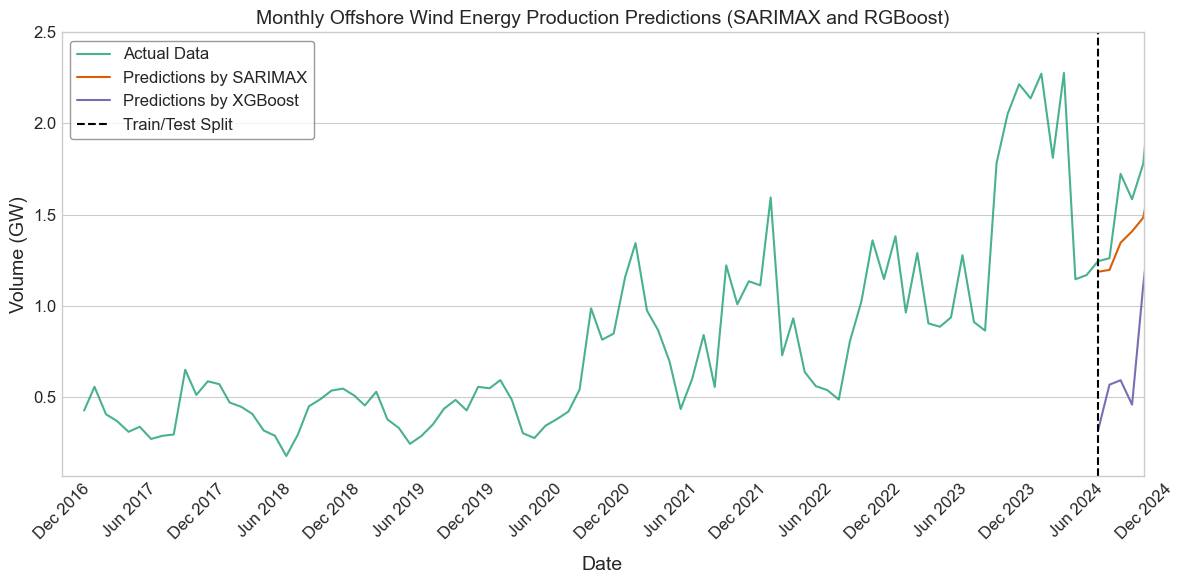

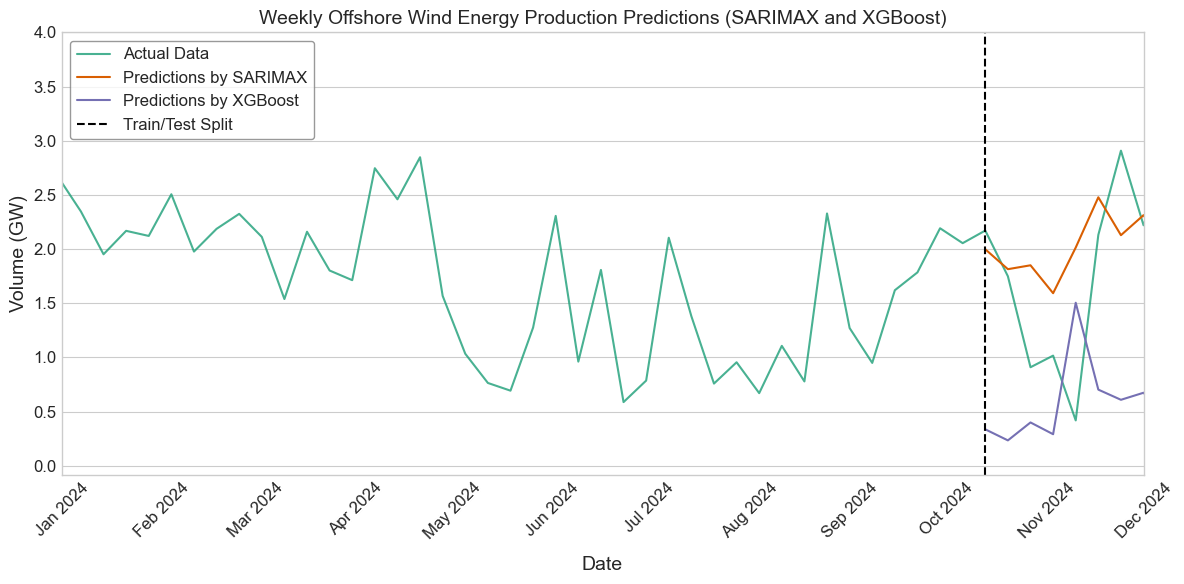

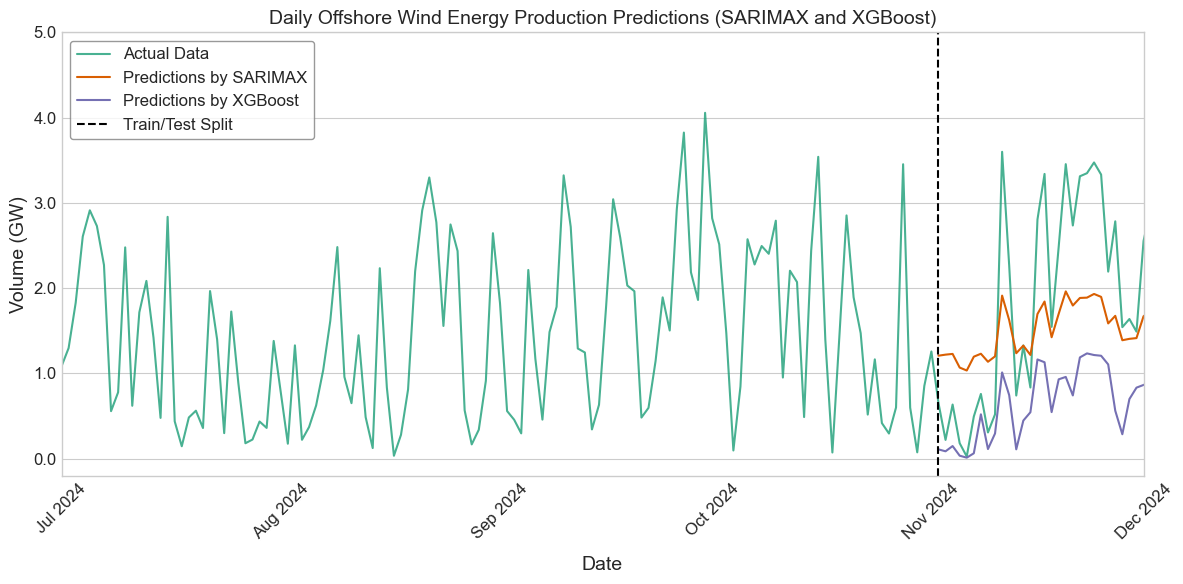

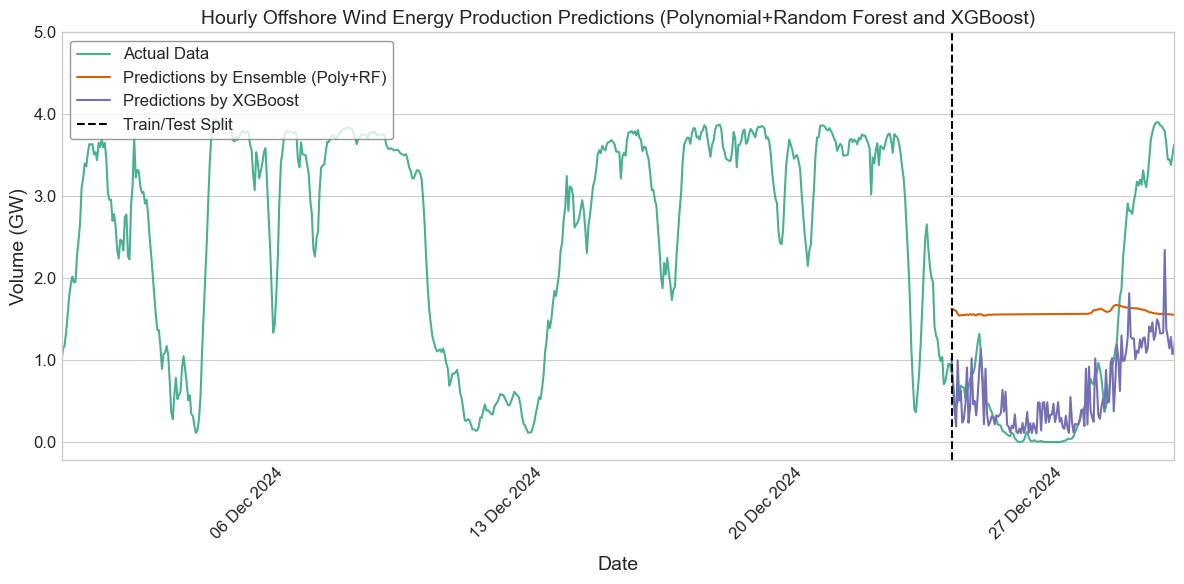

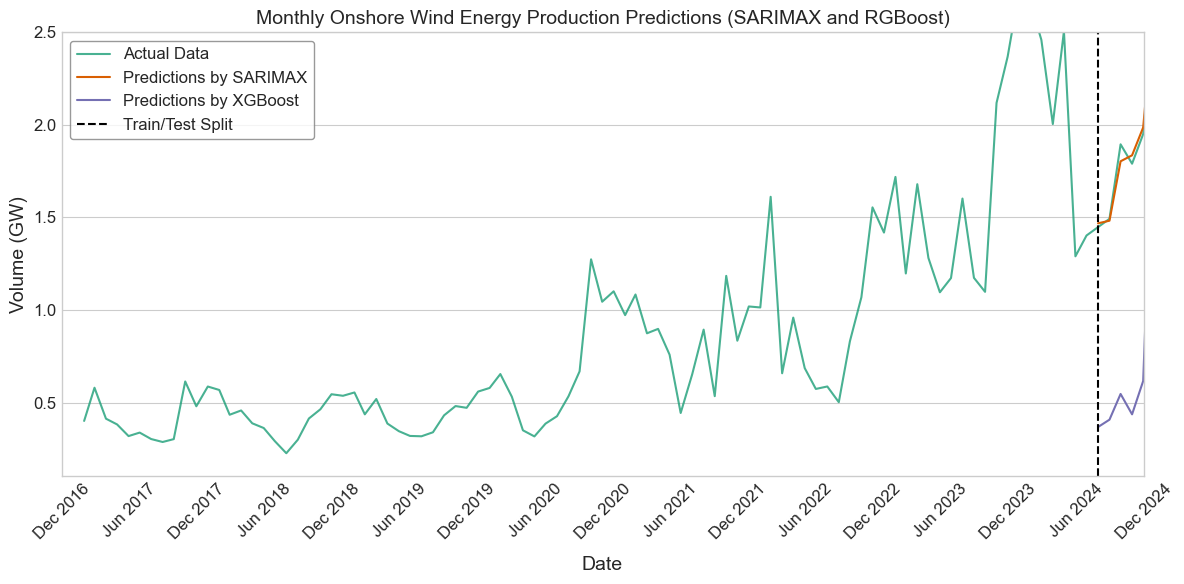

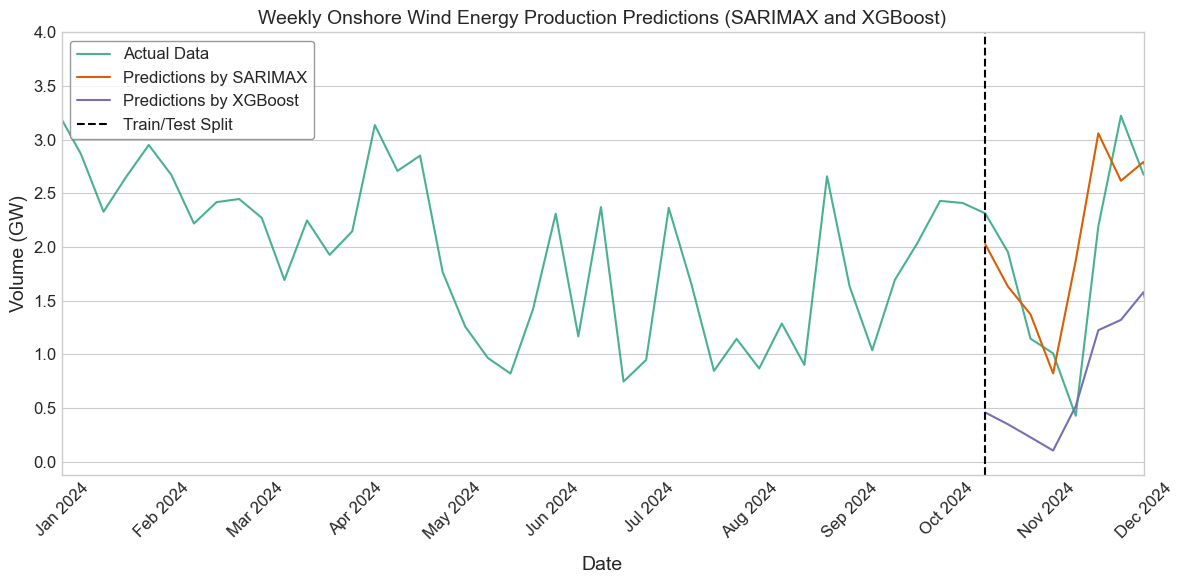

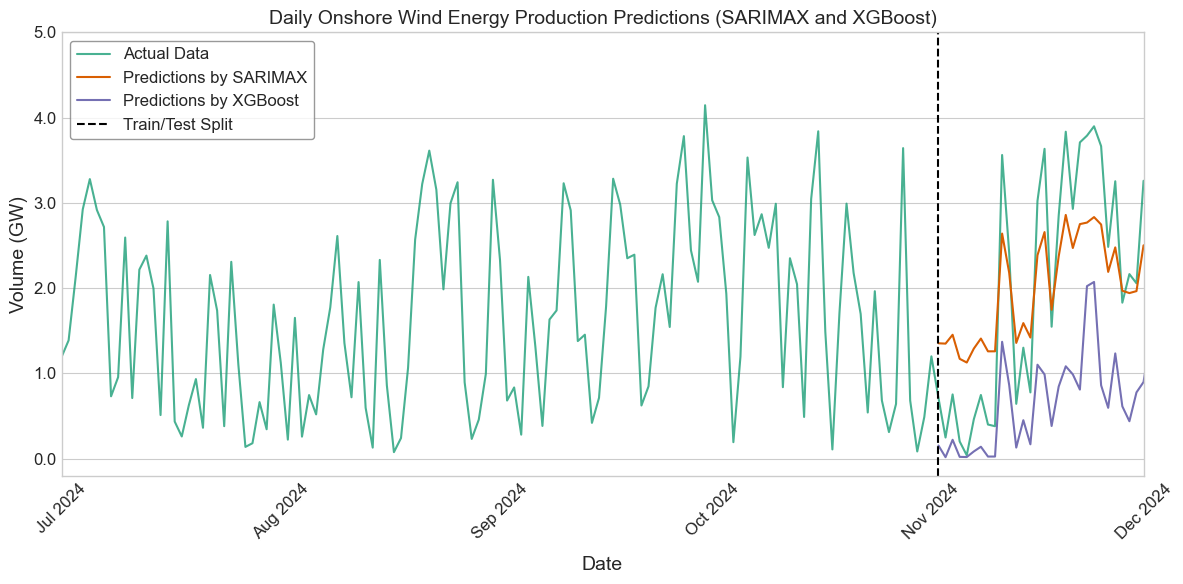

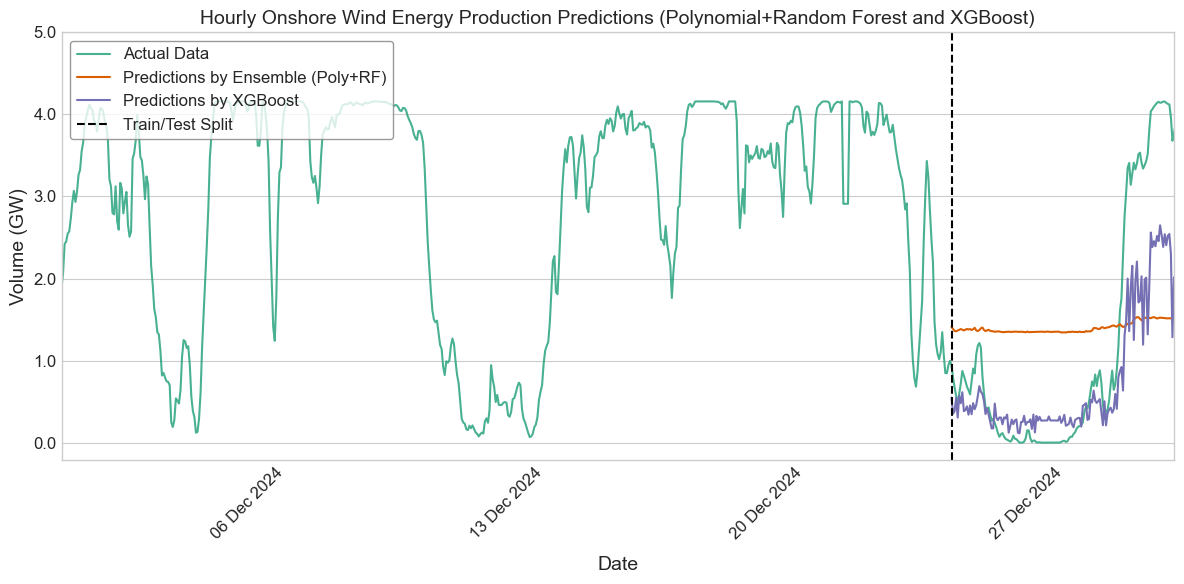

In [376]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Function to convert to millions
def millions(x, pos):
    return f'{x * 1e-6:.1f}'

# ===== Monthly - Offshore =====
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(off_df_m.index), off_df_m['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_m.index), predictions_m_off, label='Predictions by SARIMAX', color='#d95f02')
plt.plot(pd.to_datetime(y_test_off_m.index), XGB_pred_month_offshore, label='Predictions by XGBoost', color='#7570b3')
split_date = pd.to_datetime(y_test_off_m.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Monthly Offshore Wind Energy Production Predictions (SARIMAX and RGBoost)')
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GW)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2016-12'), pd.to_datetime('2024-12')) 
plt.ylim(top=2_500_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/off_m.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== Weekly - Offshore =====
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(off_df_w.index), off_df_w['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_w.index), predictions_w_off, label='Predictions by SARIMAX', color='#d95f02')
plt.plot(pd.to_datetime(y_test_off_w.index), XGB_pred_week_offshore, label='Predictions by XGBoost', color='#7570b3')
split_date = pd.to_datetime(y_test_off_w.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Weekly Offshore Wind Energy Production Predictions (SARIMAX and XGBoost)')
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GW)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01'), pd.to_datetime('2024-12')) 
plt.ylim(top=4_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/off_w.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== Daily - Offshore =====
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(off_df_d.index), off_df_d['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_d.index), predictions_d_off, label='Predictions by SARIMAX', color='#d95f02')
plt.plot(pd.to_datetime(y_test_off_d.index), XGB_pred_day_offshore, label='Predictions by XGBoost', color='#7570b3')
split_date = pd.to_datetime(y_test_off_d.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Daily Offshore Wind Energy Production Predictions (SARIMAX and XGBoost)')
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GW)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-07'), pd.to_datetime('2024-12')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/off_d.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== Hourly - Offshore =====
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(off_df.index), off_df['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_h.index), ens_pred_off_h, label='Predictions by Ensemble (Poly+RF)', color='#d95f02')
plt.plot(pd.to_datetime(y_test_off_h.index), XGB_pred_offshore, label='Predictions by XGBoost', color='#7570b3')
split_date = pd.to_datetime(y_test_off_h.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Hourly Offshore Wind Energy Production Predictions (Polynomial+Random Forest and XGBoost)')
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GW)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xlim(pd.to_datetime('2024-12-01'), pd.to_datetime('2024-12-31')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='upper left', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/off_h.png', dpi=300, bbox_inches='tight')
plt.show()


# ===== Monthly - onshore =====
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(on_df_m.index), on_df_m['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_m.index), predictions_m_on, label='Predictions by SARIMAX', color='#d95f02')
plt.plot(pd.to_datetime(y_test_on_m.index), XGB_pred_month_onshore, label='Predictions by XGBoost', color='#7570b3')
split_date = pd.to_datetime(y_test_on_m.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Monthly Onshore Wind Energy Production Predictions (SARIMAX and RGBoost)')
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GW)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2016-12'), pd.to_datetime('2024-12')) 
plt.ylim(top=2_500_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/on_m.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== Weekly - onshore =====
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(on_df_w.index), on_df_w['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_w.index), predictions_w_on, label='Predictions by SARIMAX', color='#d95f02')
plt.plot(pd.to_datetime(y_test_on_w.index), XGB_pred_week_onshore, label='Predictions by XGBoost', color='#7570b3')
split_date = pd.to_datetime(y_test_on_w.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Weekly Onshore Wind Energy Production Predictions (SARIMAX and XGBoost)')
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GW)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01'), pd.to_datetime('2024-12')) 
plt.ylim(top=4_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='upper left', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/on_w.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== Daily - onshore =====
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(on_df_d.index), on_df_d['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_d.index), predictions_d_on, label='Predictions by SARIMAX', color='#d95f02')
plt.plot(pd.to_datetime(y_test_on_d.index), XGB_pred_day_onshore, label='Predictions by XGBoost', color='#7570b3')
split_date = pd.to_datetime(y_test_on_d.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Daily Onshore Wind Energy Production Predictions (SARIMAX and XGBoost)')
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GW)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-07'), pd.to_datetime('2024-12')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/on_d.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== Hourly - onshore =====
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(on_df.index), on_df['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_h.index), ens_pred_on_h, label='Predictions by Ensemble (Poly+RF)', color='#d95f02')
plt.plot(pd.to_datetime(y_test_on_h.index), XGB_pred_onshore, label='Predictions by XGBoost', color='#7570b3')
split_date = pd.to_datetime(y_test_on_h.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Hourly Onshore Wind Energy Production Predictions (Polynomial+Random Forest and XGBoost)')
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GW)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xlim(pd.to_datetime('2024-12-01'), pd.to_datetime('2024-12-31')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='upper left', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/on_h.png', dpi=300, bbox_inches='tight')
plt.show()
